# <a id='toc1_'></a>[T23 State Space Control](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [T23 State Space Control](#toc1_)    
- [Combined estimator/regulator design for a simple satellite model](#toc2_)    
- [follows FPE 9.2 (fourth edition)](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [57]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp

import control as ct
import control.matlab as cmat

from scipy.optimize import minimize
from scipy.signal import butter,bessel

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

from scipy.signal import BadCoefficients
warnings.filterwarnings(
    "ignore",
    category=BadCoefficients
)

# <a id='toc2_'></a>[Combined estimator/regulator design for a simple satellite model](#toc0_)
# <a id='toc3_'></a>[follows FPE 9.2 (fourth edition)](#toc0_)

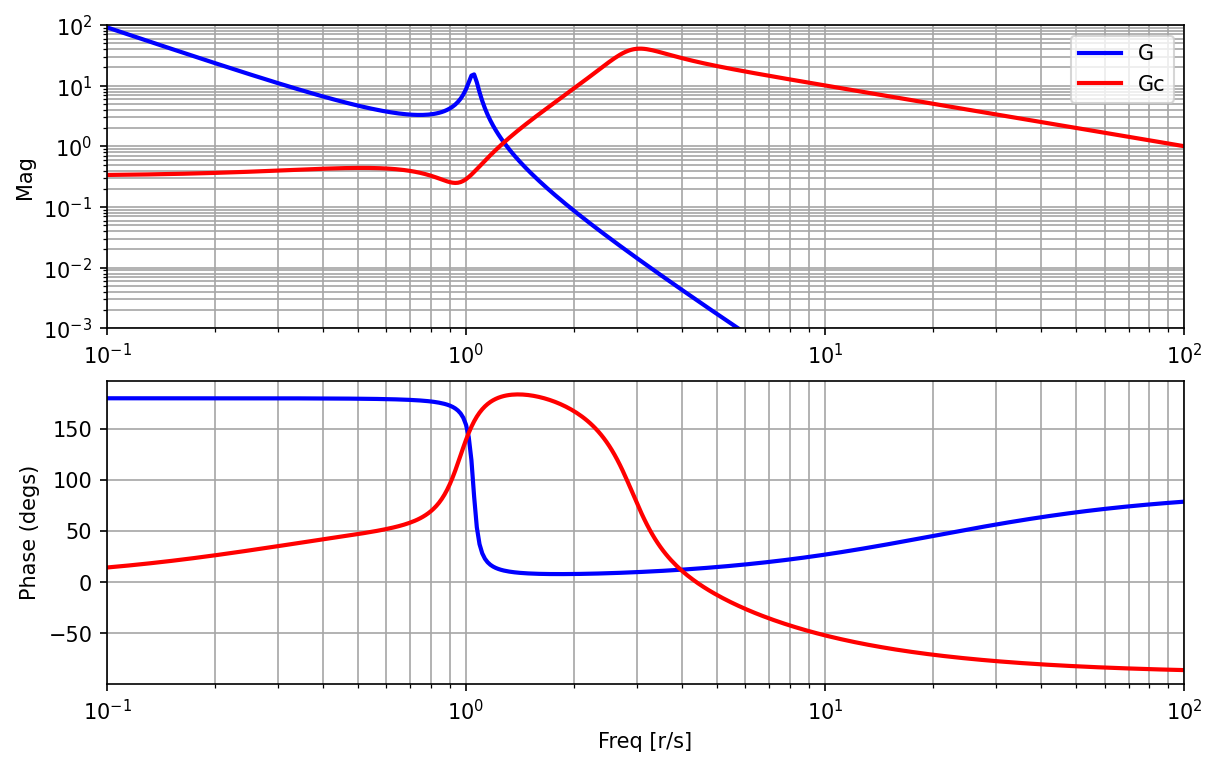

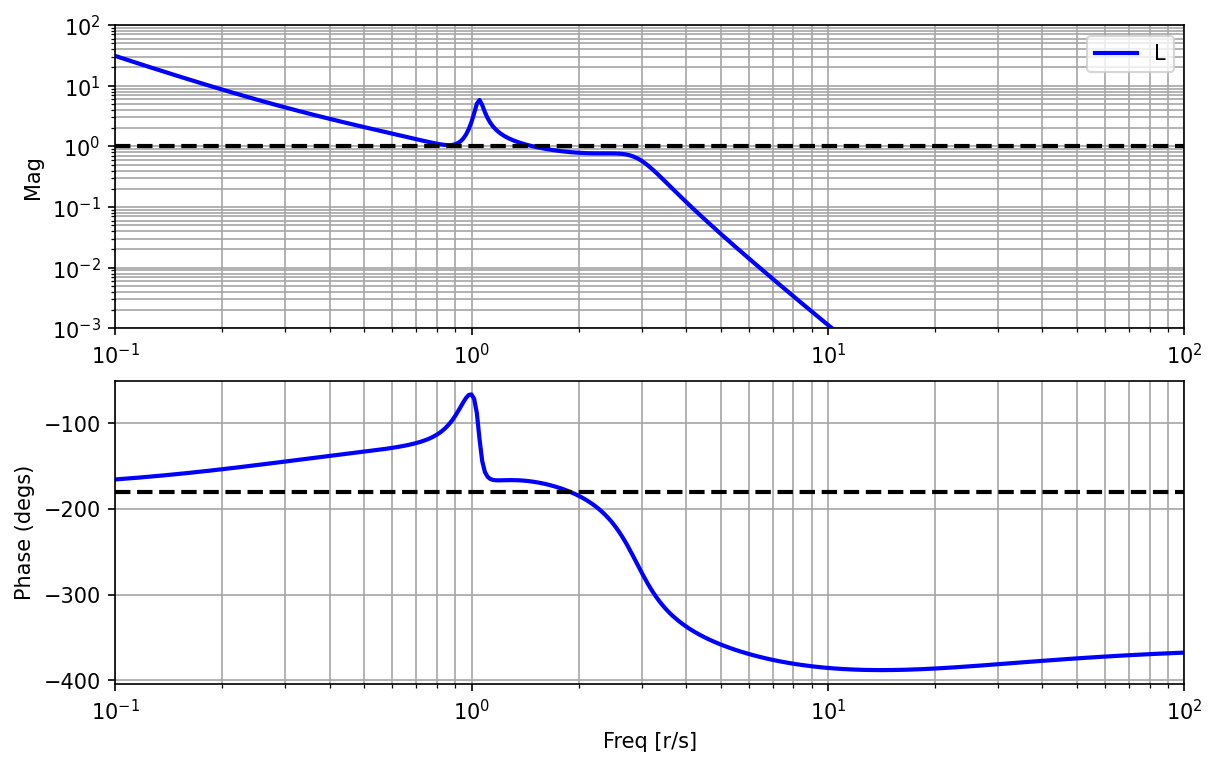


Found break-in/out at K =  1.011
At possible locations s = -1.352

Found break-in/out at K =  0.000
At possible locations s = -0.000


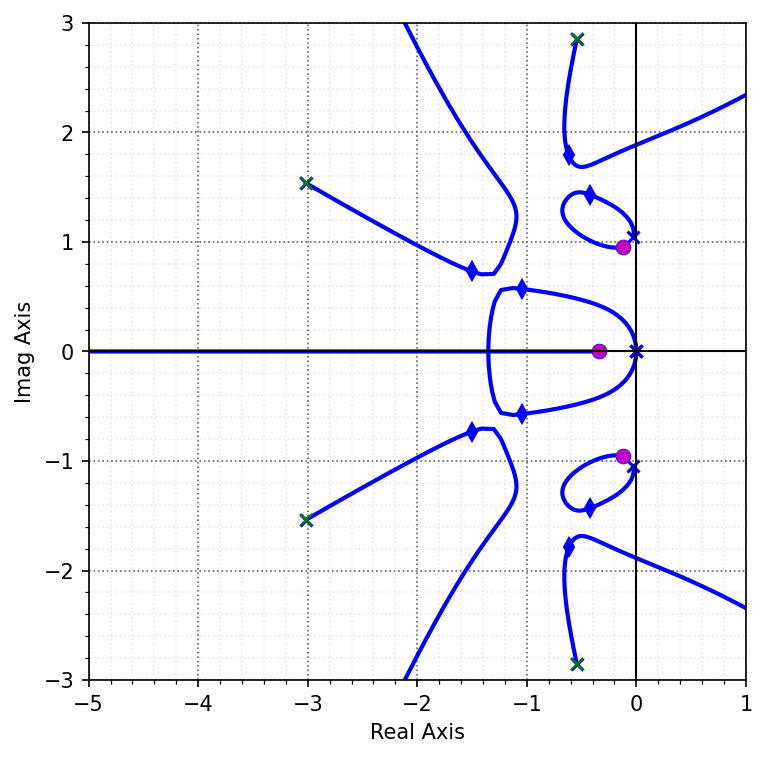

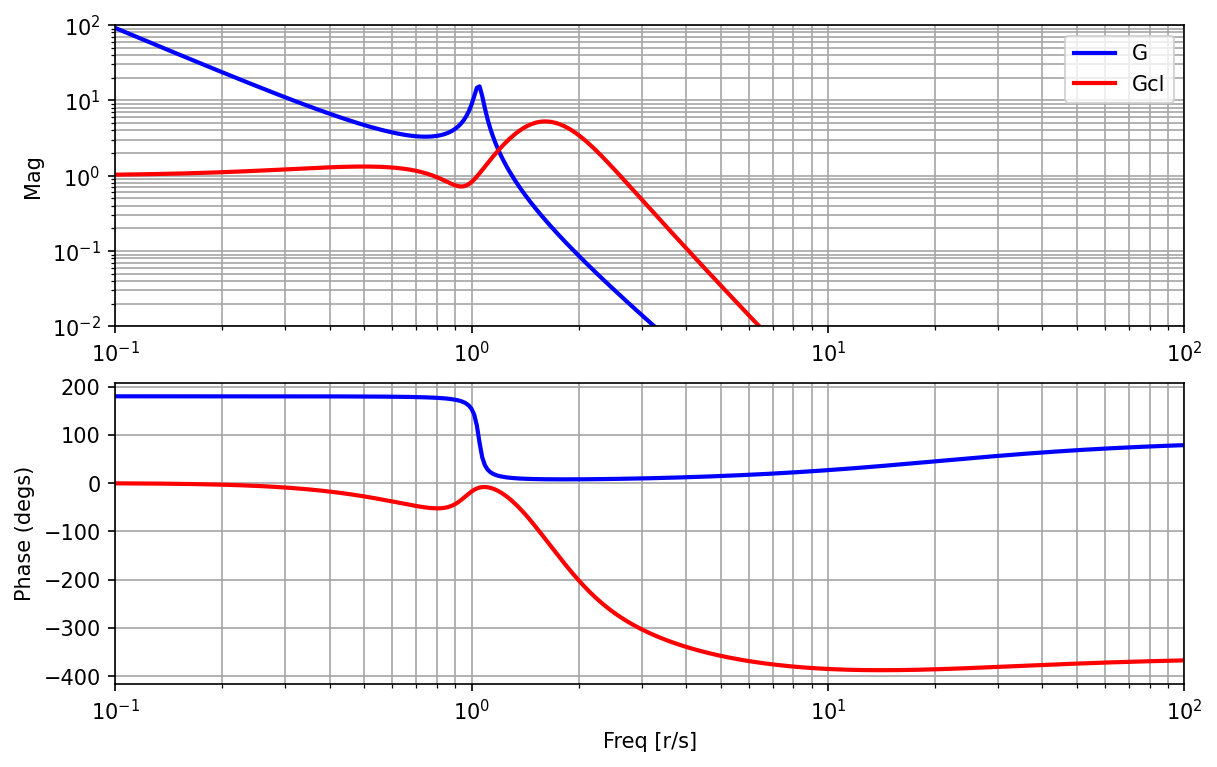

In [58]:
kk = 0.1
bb = 0.05*np.sqrt(kk/10)
J1 = 1
J2 = 0.1

# model
a = np.array([[0, 1, 0, 0],[-kk/J2, -bb/J2, kk/J2, bb/J2],[0, 0, 0, 1],[kk/J1, bb/J1, -kk/J1, -bb/J1]])
nx = a.shape[0]
b = np.array([0, 0, 0, 1/J1]).reshape(nx,1);
c = np.array([1, 0, 0, 0])
d = 0
G = ct.ss(a,b,c,d) 
nx = G.A.shape[0]
nu = G.B.shape[1]
ny = G.C.shape[0]

Rxx = G.C.T @ G.C if c.ndim == 2 else np.outer(G.C, G.C)
Ruu = 0.1
Rww = G.B @ G.B.T if b.ndim == 2 else np.outer(G.B, G.B)
Rvv = 0.01

# design DOFB controller
k, _, _ = ct.lqr(G.A, G.B, Rxx, Ruu)
k = np.asarray(k).ravel()
# k should be (nu, nx) -> flattened to (nx,) for single input

assert k.shape == (nx,), \
    f"LQR gain k has shape {k.shape}, expected ({nx},)"

# design estimator (dual LQR)
l, _, _ = ct.lqr(G.A.T, G.C.reshape(nx, 1), Rww, Rvv)
l = np.asarray(l).T

assert l.shape == (nx, ny), \
    f"Estimator gain l has shape {l.shape}, expected ({nx}, {ny})"

# For state space for G_c(s)
Gc = ct.ss(G.A-G.B*k-l*G.C,l,k,0)
#
# loop dynamics L = G Gc
#
al = np.vstack((np.hstack((G.A,G.B*Gc.C)),np.hstack((np.zeros((nx,nx)),Gc.A))))
bl = np.vstack((np.zeros((nx,1)), Gc.B ))
cl = np.hstack((G.C.reshape(1,nx), np.zeros((1,nx)) ))
dl = 0
L = ct.ss(al,bl,cl,dl)
#

# closed-loop dynamics
# unity gain wrapped around loop L
Gcl = ct.ss(L.A - L.B*L.C,L.B,L.C,L.D)
# scale closed-loop to get zero SS error
N = np.linalg.inv(Gcl.C@np.linalg.inv(-Gcl.A)@Gcl.B)
Gcl = Gcl*N
scl = Gcl.poles()
sc = Gc.poles()
zc = Gc.zeros()

# freq resp
w = np.logspace(-1,2,400)
Gf = G(w*j)
Gcf = Gc(j*w)
Lf = L(j*w)
Gclf = Gcl(j*w)

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
ax[1].semilogx(w,np.unwrap(np.angle(Gf))*cm.r2d,'b',label=r'G')
ax[0].loglog(w,np.abs(Gcf),'r',label=r'Gc')
ax[1].semilogx(w,np.unwrap(np.angle(Gcf))*cm.r2d,'r',label=r'Gc')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].legend()
ax[0].set_ylim(1e-3,100)
plt.savefig("figs/DOFB_sat_0.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Lf),'b',label=r'L')
ax[1].semilogx(w,np.unwrap(np.angle(Lf))*cm.r2d,'b',label=r'L')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].axhline(y=1,c='k',ls='--')
ax[1].axhline(y=-180,c='k',ls='--')
ax[0].legend()
ax[0].set_ylim(1e-3,100)
plt.savefig("figs/DOFB_sat_1.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist = cm.Root_Locus_gains(ct.ss2tf(L),Krange = np.logspace(-3, 3, num=10000))
rl = ct.rlocus(L, gains=klist,ax=ax,color='b')
plt.plot(np.real(scl),np.imag(scl),'bd')
plt.plot(np.real(sc),np.imag(sc),'gx')
plt.plot(np.real(zc),np.imag(zc),'mo')
ax.set_aspect('equal')
ax.set_xlim([-5, 1]);
ax.set_ylim([-3, 3])
bm.nicegrid(ax)
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imag Axis')
plt.savefig("figs/DOFB_sat_2.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
ax[1].semilogx(w,np.unwrap(np.angle(Gf))*cm.r2d,'b',label=r'G')
ax[0].loglog(w,np.abs(Gclf),'r',label=r'Gcl')
ax[1].semilogx(w,np.unwrap(np.angle(Gclf))*cm.r2d,'r',label=r'Gcl')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].legend()
ax[0].set_ylim(1e-2,100)
plt.savefig("figs/DOFB_sat_3.pdf", dpi=600)
plt.show()

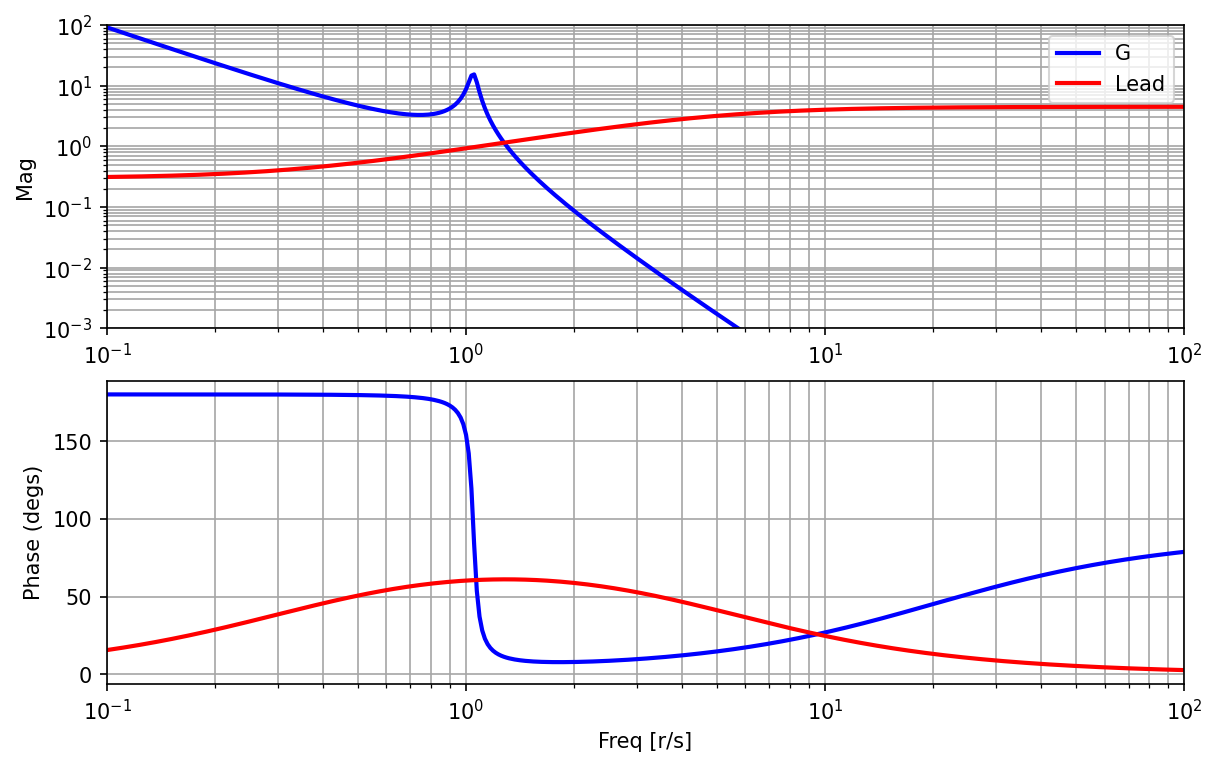

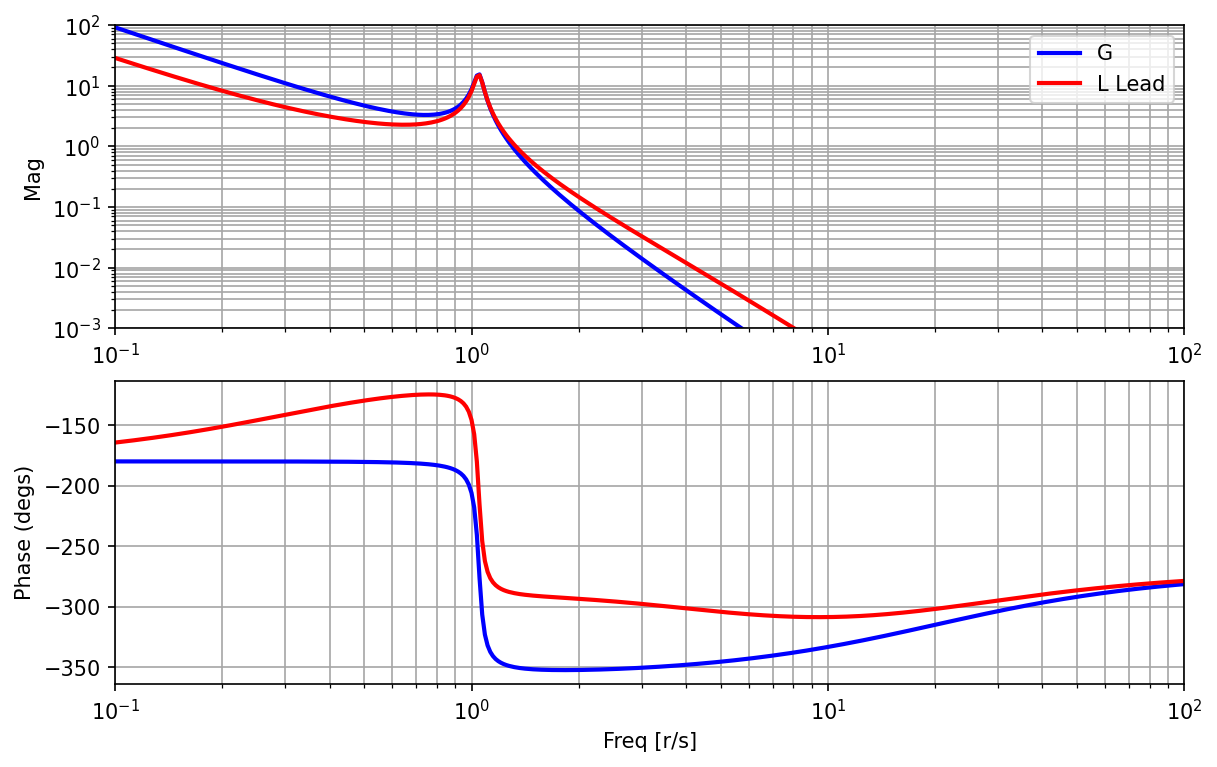

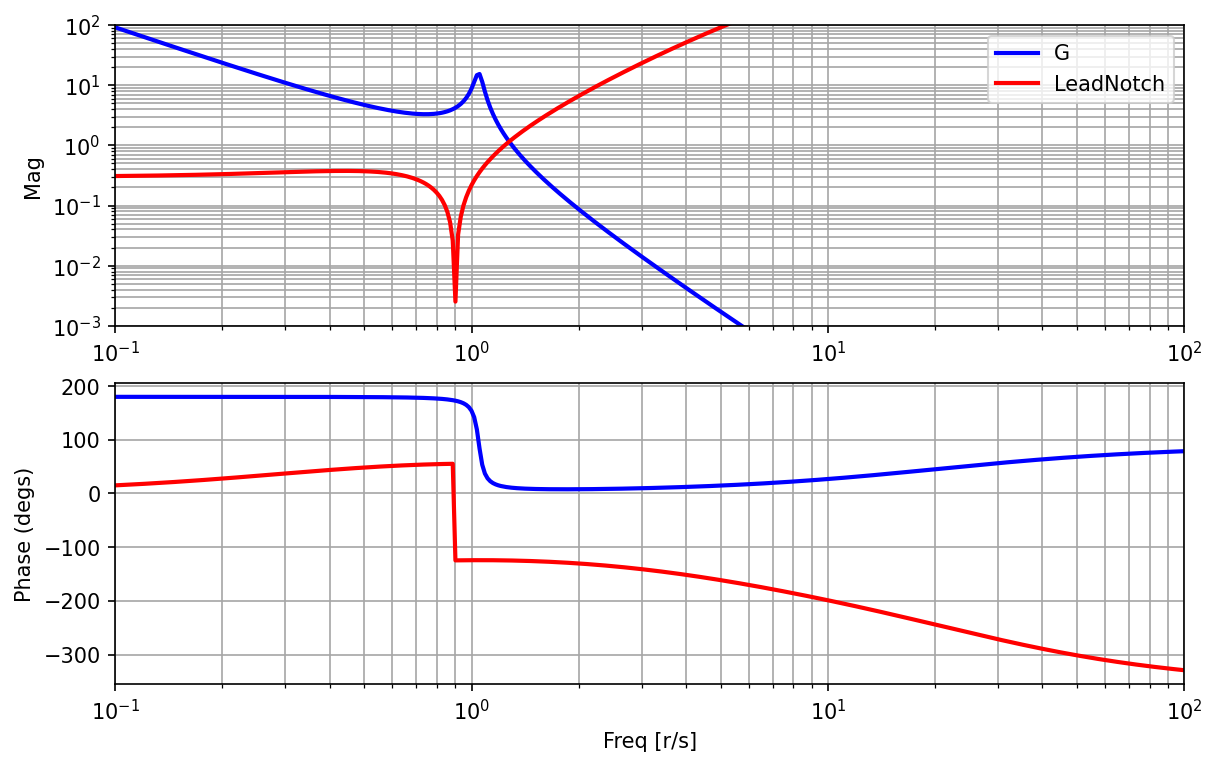

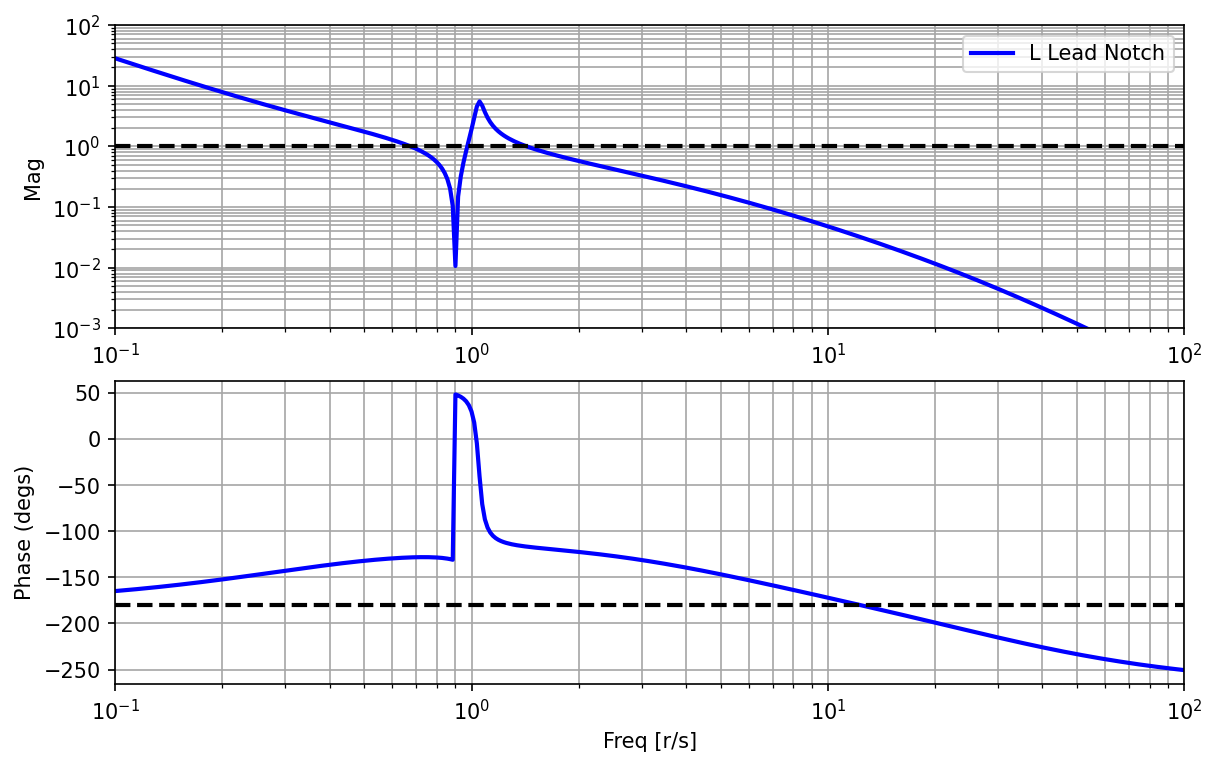

In [63]:
#
# try classical design
#
Klead = 1.5*ct.tf([3, 1],[1, 5]);
Kleadf = Klead(w*j)
LLead = G*Klead
LLeadf = LLead(j*w)
Gcl_Lead = ct.feedback(LLead,1)
scl_Lead = Gcl_Lead.poles()

KleadNotch = Klead*ct.tf([1, 0, .9**2],[1, 2*25, 25**2])/.9**2*25**2;
KleadNotchf = KleadNotch(w*j)

LLeadNotch = G*KleadNotch
LLeadNotchf = LLeadNotch(j*w)
Gcl_LeadNotch = ct.feedback(LLeadNotch,1)
scl_LeadNotch = Gcl_LeadNotch.poles()

if 1:
    fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
    ax[1].semilogx(w,np.unwrap(np.angle(Gf))*cm.r2d,'b',label=r'G')
    ax[0].loglog(w,np.abs(Kleadf),'r',label=r'Lead')
    ax[1].semilogx(w,np.unwrap(np.angle(Kleadf))*cm.r2d,'r',label=r'Lead')
    ax[1].set_xlabel('Freq [r/s]')
    ax[0].set_ylabel('Mag')
    ax[1].set_ylabel('Phase (degs)')
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].legend()
    ax[0].set_ylim(1e-3,100)
    plt.savefig("figs/DOFB_sat_6.pdf", dpi=600)
    plt.show()

    fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
    ax[1].semilogx(w,cm.wrap_phase_neg(np.angle(Gf))*cm.r2d,'b',label=r'G')
    ax[0].loglog(w,np.abs(LLeadf),'r',label=r'L Lead')
    ax[1].semilogx(w,np.unwrap(np.angle(LLeadf))*cm.r2d,'r',label=r'L Lead')
    ax[1].set_xlabel('Freq [r/s]')
    ax[0].set_ylabel('Mag')
    ax[1].set_ylabel('Phase (degs)')
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].legend()
    ax[0].set_ylim(1e-3,100)
    plt.savefig("figs/DOFB_sat_6a.pdf", dpi=600)
    plt.show()

    fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
    ax[1].semilogx(w,np.unwrap(np.angle(Gf))*cm.r2d,'b',label=r'G')
    ax[0].loglog(w,np.abs(KleadNotchf),'r',label=r'LeadNotch')
    ax[1].semilogx(w,np.unwrap(np.angle(KleadNotchf))*cm.r2d,'r',label=r'LeadNotch')
    ax[1].set_xlabel('Freq [r/s]')
    ax[0].set_ylabel('Mag')
    ax[1].set_ylabel('Phase (degs)')
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].legend()
    ax[0].set_ylim(1e-3,100)
    plt.savefig("figs/DOFB_sat_7.pdf", dpi=600)
    plt.show()

    fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax[0].loglog(w,np.abs(LLeadNotchf),'b',label=r'L Lead Notch')
    ax[1].semilogx(w,np.unwrap(np.angle(LLeadNotchf))*cm.r2d,'b',label=r'L Lead Notch')
    ax[1].set_xlabel('Freq [r/s]')
    ax[0].set_ylabel('Mag')
    ax[1].set_ylabel('Phase (degs)')
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].axhline(y=1,c='k',ls='--')
    ax[1].axhline(y=-180,c='k',ls='--')
    ax[0].legend()
    ax[0].set_ylim(1e-3,100)
    plt.savefig("figs/DOFB_sat_8.pdf", dpi=600)
    plt.show()



Found break-in/out at K = 21.045
At possible locations s = -3.750

Found break-in/out at K =  1.938
At possible locations s = -0.579

Found break-in/out at K =  0.000
At possible locations s = -0.000


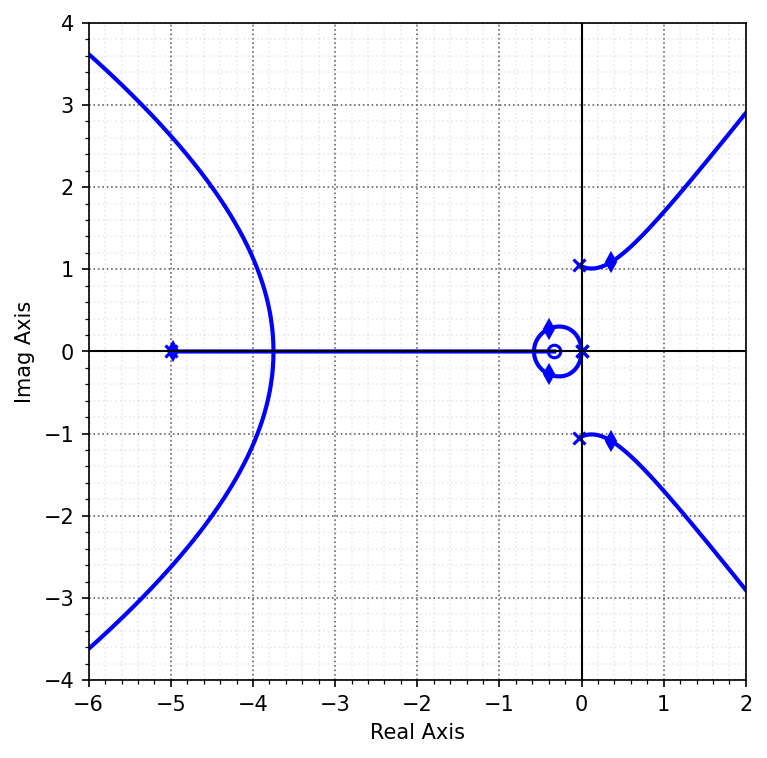


Found break-in/out at K =  1.265
At possible locations s = -1.971

Found break-in/out at K =  1.179
At possible locations s = -0.888

Found break-in/out at K =  0.000
At possible locations s = -25.000, -0.000


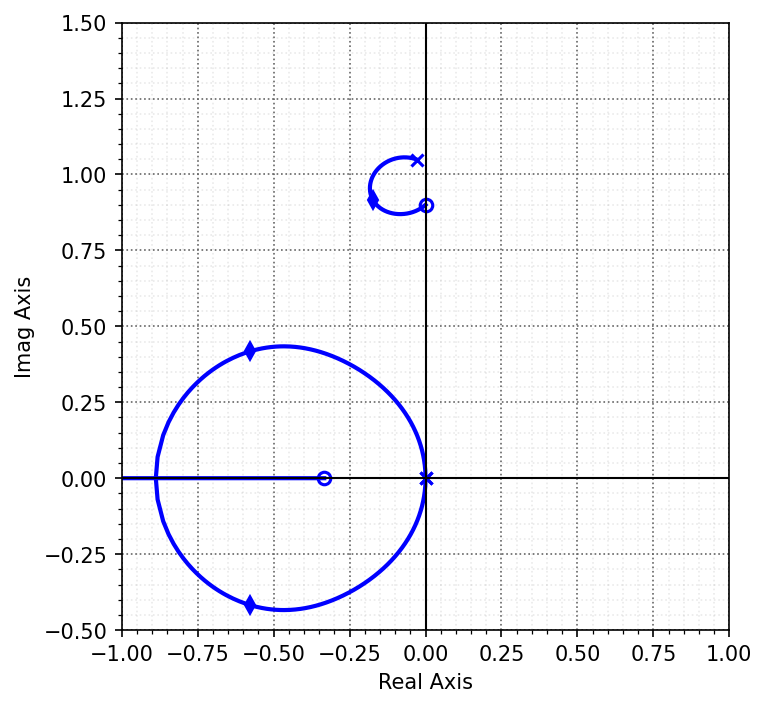

In [60]:
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
rl = ct.rlocus(LLead, gains=cm.Root_Locus_gains(ct.ss2tf(LLead)), ax=ax,color='b')
ax.set_aspect('equal')
ax.set_xlim([-6, 2])
ax.set_ylim([-4, 4])
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imag Axis')
plt.plot(np.real(scl_Lead),np.imag(scl_Lead),'bd')
bm.nicegrid(ax)
plt.savefig("figs/DOFB_sat_9.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
rl = ct.rlocus(LLeadNotch, gains=cm.Root_Locus_gains(ct.ss2tf(LLeadNotch)),  ax=ax,color='b')
ax.set_aspect('equal')
ax.set_xlim([-6, 2]);
ax.set_ylim([-4, 4])
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imag Axis')
plt.plot(np.real(scl_LeadNotch),np.imag(scl_LeadNotch),'bd')
bm.nicegrid(ax)
plt.savefig("figs/DOFB_sat_10.pdf", dpi=600)
ax.set_xlim([-1, 1])
ax.set_ylim([-0.5, 1.5])
plt.savefig("figs/DOFB_sat_10_zoom.pdf", dpi=600)
plt.show()
